In [79]:
import numpy as np
import pandas as pd
from typing import Optional, Union

def broaden_spectrum(
    df: pd.DataFrame,
    broadening: str = 'gaussian',
    fwhm: float = 100.0,
    x_min: Optional[float] = None,
    x_max: Optional[float] = None,
    n_points: Optional[int] = 10000
) -> pd.DataFrame:
    """
    Уширение дискретного спектра (например, из TD-DFT) для получения непрерывной кривой.

    Параметры
    ----------
    df : pd.DataFrame
        Входные данные. Первая колонка (df.iloc[:,0]) — положение линий
        (частота в см⁻¹).
        Вторая колонка (df.iloc[:,1]) — интенсивность (например, сила осциллятора).
    broadening : {'gaussian', 'lorentzian'}, default='gaussian'
        Тип уширения (форма линии).
    fwhm : float, default=100.0
        Полная ширина на половине высоты (FWHM) в тех же единицах, что и x_unit.
    x_min : float, optional
        Минимальное значение выходной шкалы. Если не указано, берётся
        min(energy) - 5 * fwhm.
    x_max : float, optional
        Максимальное значение выходной шкалы. Если не указано, берётся
        max(energy) + 5 * fwhm.
    n_points : int, default=1000
        Количество точек на выходной шкале.

    Возвращает
    -------
    pd.DataFrame
        Датафрейм с двумя колонками: 'x' — координаты (в единицах x_unit),
        'y' — интенсивность после уширения.
        Интеграл под кривой приблизительно равен сумме исходных интенсивностей.
    """

    x0 = df.iloc[:, 0].values.astype(float)
    intensity = df.iloc[:, 1].values.astype(float)

    if len(x0) == 0:
        raise ValueError("Входной DataFrame не содержит данных.")
    if np.any(np.isnan(x0)) or np.any(np.isnan(intensity)):
        raise ValueError("Входные данные содержат NaN.")

    if x_min is None:
        x_min = np.min(x0) - 5 * fwhm
        if x_min < 0:
            x_min = 0
    if x_max is None:
        x_max = np.max(x0) + 5 * fwhm

    x = np.linspace(x_min, x_max, n_points)
    y = np.zeros_like(x)

    if broadening == 'gaussian':
        sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
        norm_factor = 1.0 / (sigma * np.sqrt(2 * np.pi))
        for xi, ii in zip(x0, intensity):
            y += ii * norm_factor * np.exp(-0.5 * ((x - xi) / sigma) ** 2)
    elif broadening == 'lorentzian':
        gamma = fwhm / 2 
        norm_factor = gamma / np.pi
        for xi, ii in zip(x0, intensity):
            y += ii * norm_factor / ((x - xi) ** 2 + gamma ** 2)
    else:
        raise ValueError("Параметр broadening должен быть 'gaussian' или 'lorentzian'.")

    return pd.DataFrame({'x': x, 'y': y})

In [80]:
import pandas as pd
from io import StringIO
from typing import Dict


def read_spectrum(filepath: str, sep: str = r'\s+') -> Dict[str, pd.DataFrame]:

    with open(filepath, 'r') as f:
        lines = [line.rstrip('\n') for line in f]
        lines = lines[2:]
    
    blocks = []
    i = 0
    n = len(lines)

    while i < n:
        while i < n and not lines[i].strip():
            i += 1
        if i >= n:
            break

        name = lines[i].strip()
        i += 1
        if i < n and not lines[i].strip():
            i += 1

        data_lines = []
        while i < n and lines[i].strip():
            data_lines.append(lines[i])
            i += 1

        if data_lines:
            blocks.append((name, data_lines))

    dataframes = {}
    for name, data_lines in blocks:
        first_line = data_lines[0].split()
        try:
            float(first_line[0])       
            header = None
        except ValueError:
            header = 0             

        data_str = '\n'.join(data_lines)
        df = pd.read_csv(StringIO(data_str), sep=sep, header=header, engine='python')
        dataframes[name] = df

    return dataframes

In [92]:
def IR_spectrum_plotting(spectrums):

    broaden_spectrums = {}
    for spectrum in spectrums:
        broaden_spectrums[spectrum] = broaden_spectrum(spectrums[spectrum], fwhm = 100.0, x_min = 0, x_max = 4000)
        plt.plot(broaden_spectrums[spectrum]['x'], broaden_spectrums[spectrum]['y'], label = spectrum)

    plt.xlabel('Frequency, cm⁻¹') 
    plt.ylabel('Intensity')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.legend()
    plt.show()

def optical_spectrum_plotting(spectrums):

    broaden_spectrums = {}
    for spectrum in spectrums:
        broaden_spectrums[spectrum] = broaden_spectrum(spectrums[spectrum], fwhm = 1000.0, x_min = 5000, x_max = 45000)
        #broaden_spectrums[spectrum]['x'] = 10 ** 7 / broaden_spectrums[spectrum]['x']
        plt.plot(broaden_spectrums[spectrum]['x'], broaden_spectrums[spectrum]['y'], label = spectrum)

    plt.xlabel('Frequency, cm⁻¹') 
    #plt.xlabel('Wavelenght, nm') 
    plt.ylabel('Forse of oscillator')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.legend()
    plt.show()

def environment_plotting(spectrums, type_of_spectrum = 'IR spectrum'):
    
    Vacuum_spectrums = {k: spectrums[k] for k in spectrums.keys() if k.startswith('GO')}
    H2O_spectrums = {k: spectrums[k] for k in spectrums.keys() if k.startswith('H2O')}
    
    if type_of_spectrum == 'IR spectrum':
        
        IR_spectrum_plotting(Vacuum_spectrums)
        IR_spectrum_plotting(H2O_spectrums)
    
    elif type_of_spectrum == 'Optical spectrum':
        
        optical_spectrum_plotting(Vacuum_spectrums)
        optical_spectrum_plotting(H2O_spectrums)

def structure_plotting(spectrums, type_of_spectrum = 'IR spectrum'):
    
    structures_spectrum = {k: spectrums[k] for k in spectrums.keys() if k.startswith('GO')}
    structures_spectrums = []
    for spectrum in structures_spectrum:
        structures_spectrums.append({k: spectrums[k] for k in spectrums.keys() if spectrum in k})
    
    if type_of_spectrum == 'IR spectrum':

        for structure in structures_spectrums:
            IR_spectrum_plotting(structure)
        
    elif type_of_spectrum == 'Optical spectrum':
        
        for structure in structures_spectrums:
            optical_spectrum_plotting(structure)

In [86]:
import matplotlib.pyplot as plt
import re

def spectrum_plotting(file, type_of_spectrum):
    
    unsorted_spectrums = read_spectrum(file)
    
    def natural_key(s):
        return [int(part) if part.isdigit() else part.lower() for part in re.split(r'(\d+)', s)]

    sorted_keys = sorted(unsorted_spectrums, key=natural_key)
    
    spectrums = {k: unsorted_spectrums[k] for k in sorted_keys}
    
    environment_plotting(spectrums, type_of_spectrum)
    structure_plotting(spectrums, type_of_spectrum)

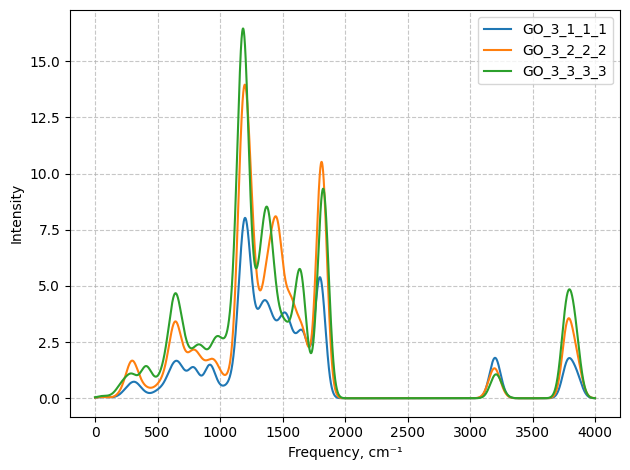

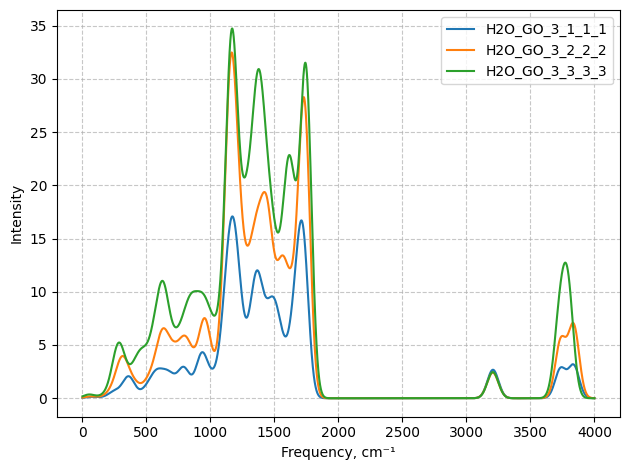

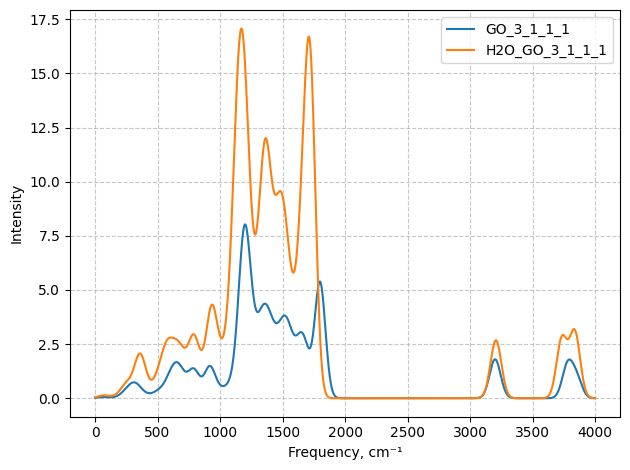

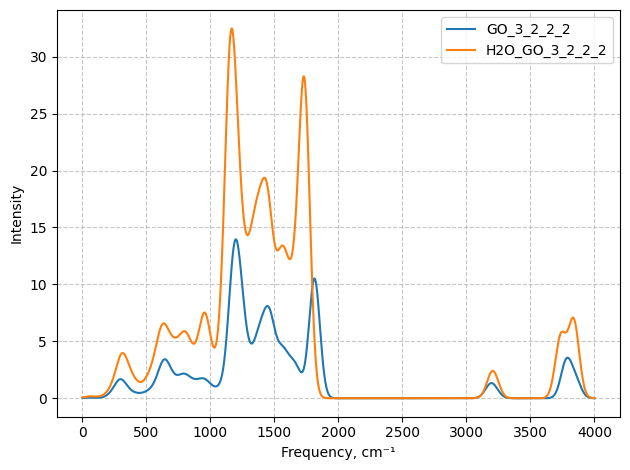

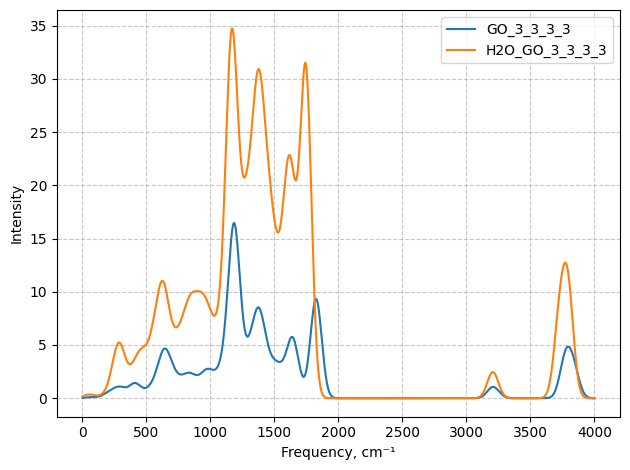

In [87]:
file = r"C:\Users\sasha\OneDrive\Desktop\IR_spectrum.txt"
spectrum_type = "IR spectrum"
spectrum_plotting(file, spectrum_type)

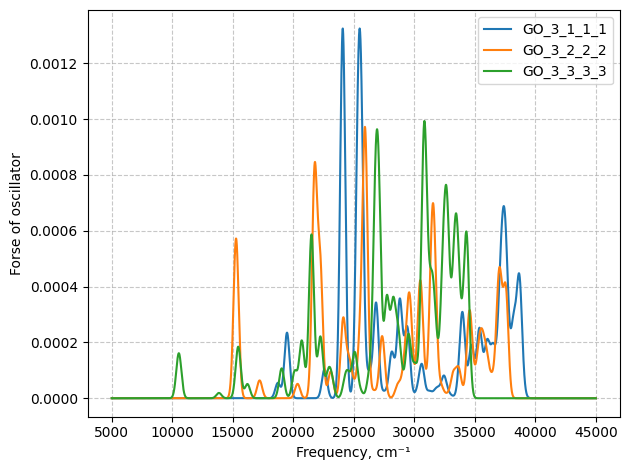

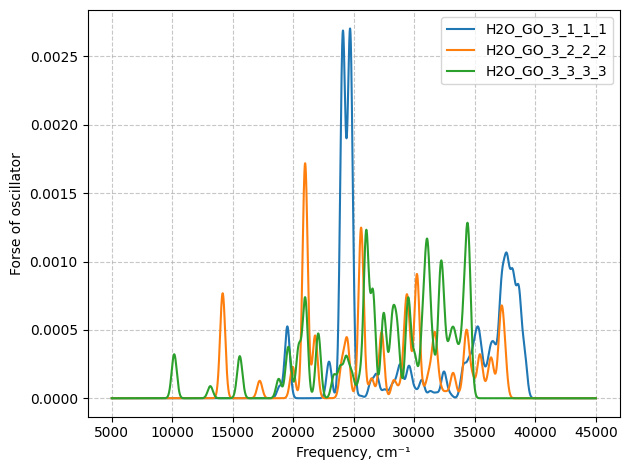

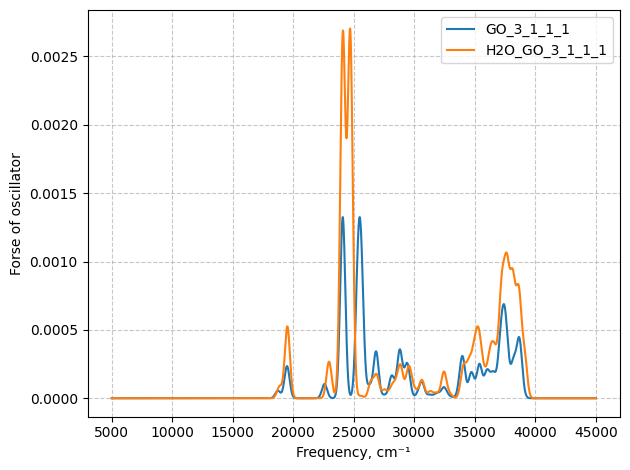

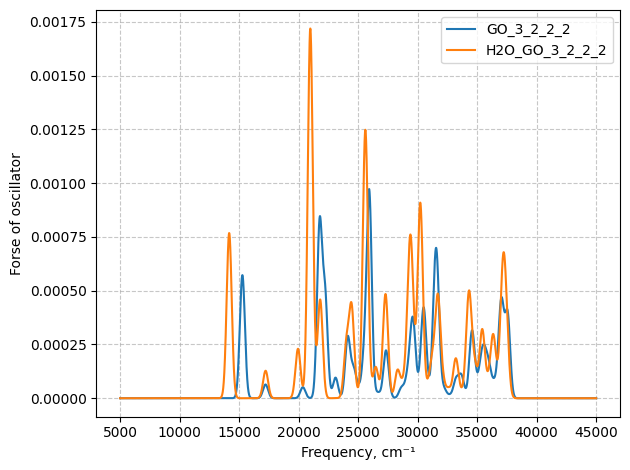

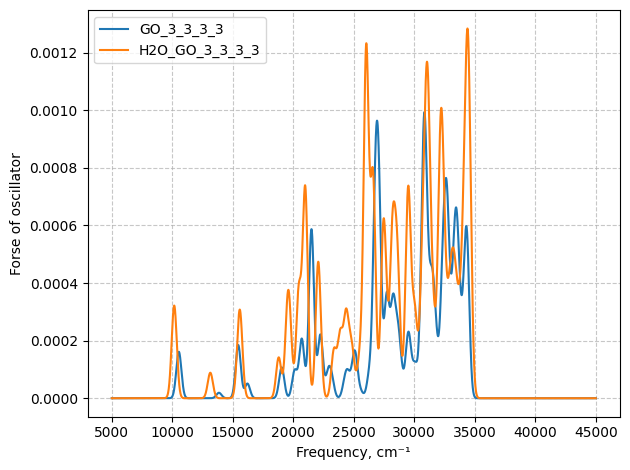

In [91]:
file = r"C:\Users\sasha\OneDrive\Desktop\Optical_spectrum.txt"
spectrum_type = "Optical spectrum"
spectrum_plotting(file, spectrum_type)